## Figure 4. Performance and thresholding of the NMWI. 


In [26]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import glob, warnings, sys, runpy
import matplotlib
# matplotlib.use("cairo")
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


In [3]:
# Run only once to get the working directory
project_root = Path("../../").resolve()
os.chdir(project_root)
print("Working dir:", Path.cwd())

Working dir: /Users/barrera.maria/Library/CloudStorage/GoogleDrive-barrera.maria1297@gmail.com/.shortcut-targets-by-id/1LkgWZVWWAMM27iFYdRSBNH8E7w0EPw9j/Maria B/Coding_projects/NMWI


In [28]:
%matplotlib inline
# METADATA LOADING
vars_dict = runpy.run_path("Codes/Auxiliary_files/Generate_data_index.py")
globals().update(vars_dict)
X_new = X.copy()

Found 27 genus tables in index
Removed 4 OTU IDs listed in OTU_IDS_TO_EXCLUDE
Number of samples: 1654, and number of taxa: 184
Number of unique studies: 27

Sample_id per Category:
Category  n_sample_id
    case         1065
 control          589


- X: DataFrame (rows=samples, cols=taxonomy), index includes bioproject/sample_id RELATIVE ABUNDANCE
- y: Series/array-like of True/False (same index as X), True (1) =control, False=case

In [29]:
%run -i Codes/Auxiliary_files/NMWI.py # Run model
%run -i Codes/Auxiliary_files/LOSO.py # Run model

###### RESULTS SUMMARY
print(f"10x10 CV BA: {scores.mean():.4f}") #print(f"10x10 CV SD: {scores.std():.4f}")
print(f"C: {C:.4f}")
print(f"LOSO: {mean_cv_ba:.4f}")
print(f"Train ba: {train_bal_acc:.4f}")
print(f"# positive coefs: {num_pos}, # negative coefs: {num_neg}, # zero coefs: {num_zero}")

/opt/anaconda3/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

NMWI fitted; 10x10cv


<Figure size 640x480 with 0 Axes>

10x10 CV BA: 0.7343
C: 0.9375
LOSO: 0.7382
Train ba: 0.7437
# positive coefs: 14, # negative coefs: 10, # zero coefs: 160


### Figure 4.a
Distribution of balanced accuracies across individual studies under LOSO CV. Bars represent the number of healthy (blue) and non-healthy (red) samples per cohort, while points indicate cohort-specific balanced accuracy (green line). The dashed line denotes the cross-cohort mean (73.82%). 

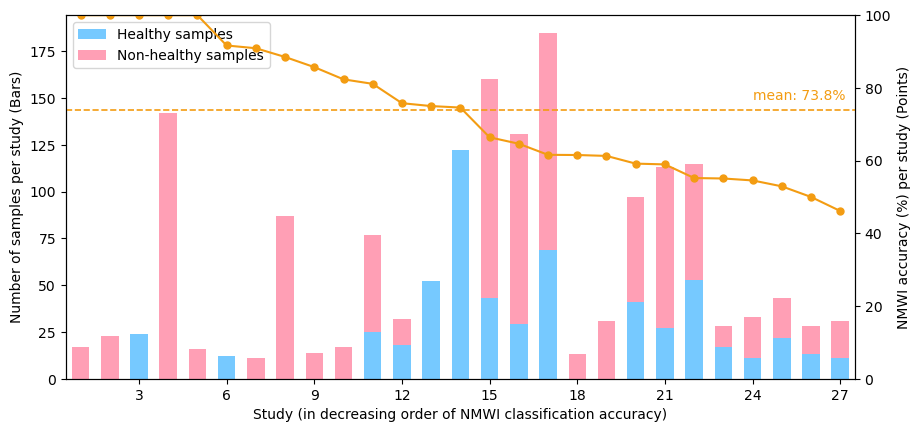

In [30]:
## Leave-one-study-out 
plot_df = loso_df.sort_values("BA", ascending=False).reset_index(drop=True)
plot_df["Study_idx"] = np.arange(1, len(plot_df) + 1)

acc_pct = plot_df["BA"] * 100
mean_acc = acc_pct.mean()

# Dimensions
width_pt = 242
height_pt = 115
width_in = width_pt /26 ; height_in = height_pt / 26

fig, ax1 = plt.subplots(figsize=(width_in, height_in))
width = 0.6

# Stacked bars: positives + negatives per held-out study
ax1.bar(
    plot_df["Study_idx"], plot_df["pos_test"],
    width=width, color="#76c9ff", edgecolor="none", label="Healthy samples"
)
ax1.bar(
    plot_df["Study_idx"], plot_df["neg_test"],
    width=width, bottom=plot_df["pos_test"],
    color="#ff9fb5", edgecolor="none", label="Non-healthy samples"
)

ax1.set_xlabel("Study (in decreasing order of NMWI classification accuracy)")
ax1.set_ylabel("Number of samples per study (Bars)")
ax1.set_xlim(0.5, len(plot_df) + 0.5)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend(loc="upper left", frameon=True)

# Line: accuracy per study
ax2 = ax1.twinx()
ax2.plot(
    plot_df["Study_idx"], acc_pct,
    "o-", linewidth=1.5, markersize=5, color="#f39c12"
)
ax2.set_ylabel("NMWI accuracy (%) per study (Points)")
ax2.set_ylim(0, 100)

# Mean accuracy reference line
ax2.axhline(mean_acc, linestyle="--", linewidth=1.2, color="#f39c12")
ax2.text(
    len(plot_df) - 3, mean_acc + 2,
    f"mean: {mean_acc:.1f}%",
    color="#f39c12", ha="left", va="bottom"
)

plt.tight_layout()

# plt.savefig("Figures/Fig3a.pdf")
plt.show()

### Figure 4b
Receiver operating characteristic curves for classification performance in distinguishing healthy and non-healthy phenotypes under resubstitution (AUROC = 0.83), 10×10 CV (AUROC = 0.81), and LOSO CV (AUROC = 0.76).

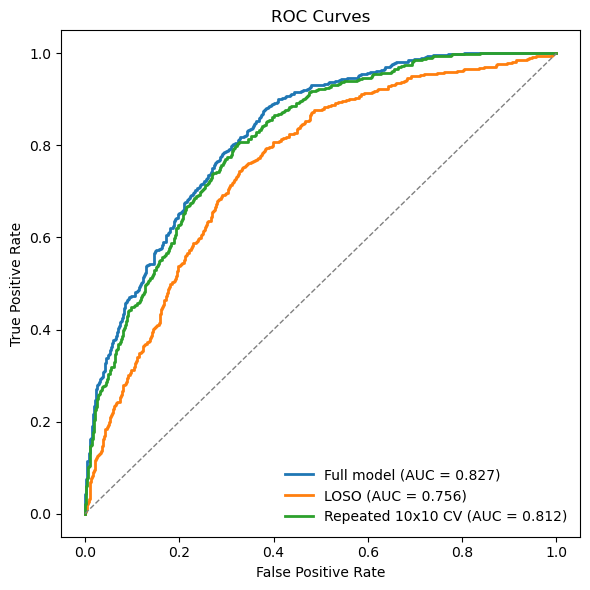

full AUC: 0.8268
LOSO (AUC = 0.7555)
Repeated 10x10 CV (AUC = 0.8125)


In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

# Full model
full_auc = roc_auc_score(y.values, scores_all)
fpr_full, tpr_full, _ = roc_curve(y.values, scores_all)

# LOSO
loso_auc = roc_auc_score(y_arr, loso_scores)
fpr_loso, tpr_loso, _ = roc_curve(y_arr, loso_scores)

# 10x10cv
cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# each sample gets one test prediction per repeat, so we average them
cv_scores_sum = np.zeros(len(y))
cv_scores_count = np.zeros(len(y))

for train_idx, test_idx in cv.split(X_new, y.values):
    X_tr = X_new.iloc[train_idx]
    X_te = X_new.iloc[test_idx]
    y_tr = y.values[train_idx]

    model_10 = LogisticRegression(**final_params)
    model_10.fit(X_tr, y_tr)

    fold_scores = model_10.decision_function(X_te)
    cv_scores_sum[test_idx] += fold_scores
    cv_scores_count[test_idx] += 1

cv_scores_mean = cv_scores_sum / cv_scores_count

cv_auc = roc_auc_score(y.values, cv_scores_mean)
fpr_cv, tpr_cv, _ = roc_curve(y.values, cv_scores_mean)

# --------------------------------------------------
# 4. PLOT
# --------------------------------------------------
plt.figure(figsize=(6, 6))

plt.plot(fpr_full, tpr_full, lw=2, label=f"Full model (AUC = {full_auc:.3f})")
plt.plot(fpr_loso, tpr_loso, lw=2, label=f"LOSO (AUC = {loso_auc:.3f})")
plt.plot(fpr_cv, tpr_cv, lw=2, label=f"Repeated 10x10 CV (AUC = {cv_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('Figures/Fig3b.pdf')
plt.show()

print(f'full AUC: {full_auc:.4f}')
print(f"LOSO (AUC = {loso_auc:.4f})")
print(f"Repeated 10x10 CV (AUC = {cv_auc:.4f})")

### Figure 4.c
LODO analysis of generalizability across disease conditions.

Total LODO folds (including healthy): 8
    Disease  n_test  pos_test  neg_test        BA
5       GPA      68       589        68  0.308824
6        RA      21       589        21  0.333333
3       CRS     652       589       652  0.664110
4  CRS + AS      34       589        34  0.705882
0        AR     137       589       137  0.708029
1    Asthma     123       589       123  0.821138
2        CF      30       589        30  0.933333
LODO mean balanced accuracy: 0.6392357695614095


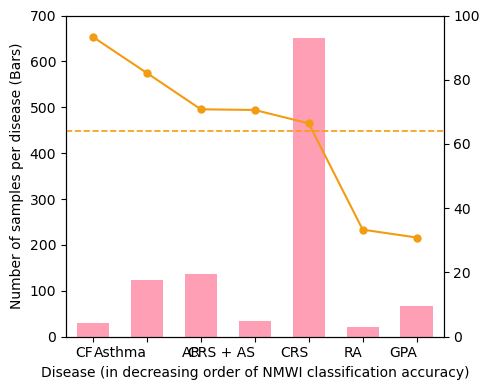

In [32]:
## lodo
temp_t = training_set.reset_index()
temp_t = temp_t.set_index(['BioProject.Number', 'Disease', 'Sample_id'])
X_lodo = temp_t[[c for c in temp_t.columns if c.startswith("d__")]]

disease_ids = np.array(X_lodo.index.get_level_values("Disease"))

lodo = LeaveOneGroupOut()
lodo_splits = list(lodo.split(X_lodo, y_arr, groups=disease_ids))
print("Total LODO folds (including healthy):", len(lodo_splits))

fold_bas = []
lodo_loop = []

for train_idx, test_idx in lodo_splits:
    disease_te = pd.Index(disease_ids[test_idx]).unique().tolist()[0]

    if str(disease_te) == "Healthy":
        continue

    X_tr = X_lodo.iloc[train_idx]
    y_tr = y_arr[train_idx]
    X_te = X_lodo.iloc[test_idx]
    y_te = y_arr[test_idx]

    disease_train = disease_ids[train_idx]
    disease_train_ser = pd.Series(disease_train)

    lodo_model = LogisticRegression(**final_params)
    lodo_model.fit(X_tr, y_tr)

    y_hat = lodo_model.predict(X_te)
    ba = balanced_accuracy_score(y_te, y_hat) 
    fold_bas.append(ba)

    pos_test = int(y_tr.sum())
    neg_test = int((~pd.Series(y_te.astype(bool))).sum())

    lodo_loop.append({
        "Disease": disease_te,
        "n_test": len(test_idx),
        "pos_test": pos_test,
        "neg_test": neg_test,
        "BA": ba 
    })

lodo_df = pd.DataFrame(lodo_loop).sort_values("BA")
print(lodo_df)

mean_cv_ba = float(np.mean(fold_bas)) if fold_bas else np.nan
print("LODO mean balanced accuracy:", mean_cv_ba)

plot_df = lodo_df.sort_values("BA", ascending=False).reset_index(drop=True)
plot_df["Disease_idx"] = np.arange(1, len(plot_df) + 1)

acc_pct = plot_df["BA"] * 100
mean_acc = acc_pct.mean()

fig, ax1 = plt.subplots(figsize=(5, 4))

ax1.bar(
    plot_df["Disease_idx"],
    plot_df["neg_test"],              # non-healthy samples in test fold
    width=width,
    # bottom=plot_df["pos_test"],       # <<-- stack
    color="#ff9fb5",
    edgecolor="none",
    label="Non-healthy samples"
)

ax1.set_xlabel("Disease (in decreasing order of NMWI classification accuracy)")
ax1.set_ylabel("Number of samples per disease (Bars)")
ax1.set_xlim(0.5, len(plot_df) + 0.5)
ax1.set_ylim(0,700)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

ax1.set_xticks(plot_df["Disease_idx"])
ax1.set_xticklabels(plot_df["Disease"], ha="right")

ax2 = ax1.twinx()
ax2.plot(
    plot_df["Disease_idx"],
    acc_pct,
    "o-",
    linewidth=1.5,
    markersize=5,
    color="#f39c12"
)

ax2.axhline(mean_acc, linestyle="--", linewidth=1.2, color="#f39c12")
ax2.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("Figures/Fig3c.pdf")
plt.show()

### Figure 4.d
Increasing the magnitude cutoff improves classification performance, while reducing the proportion of samples retained. Balanced accuracies from 10×10 CV is shown in blue (±SD shading), with the percentage of retained samples in yellow (±SD shading). 

,cutoff,samples retained,samples retained sd,bal_acc,bal_acc sd,recall,tnr
0,0.0,1.000000,0.000000,0.734349,0.035282,0.773869,0.694829
1,0.1,0.936942,0.018216,0.750215,0.037531,0.794526,0.705904
2,0.2,0.861482,0.027538,0.765607,0.040157,0.816001,0.715213
3,0.3,0.777924,0.030798,0.786385,0.038532,0.848478,0.724291
4,0.4,0.706043,0.033470,0.801137,0.037884,0.868312,0.733961
5,0.5,0.641903,0.036007,0.814238,0.039744,0.879525,0.748951
6,0.6,0.567284,0.044600,0.833360,0.042162,0.886140,0.780581
7,0.7,0.487779,0.045882,0.851946,0.040719,0.884861,0.819032
8,0.8,0.409426,0.042836,0.871035,0.046644,0.886038,0.856032
9,0.9,0.354396,0.037560,0.893471,0.047090,0.898472,0.888469


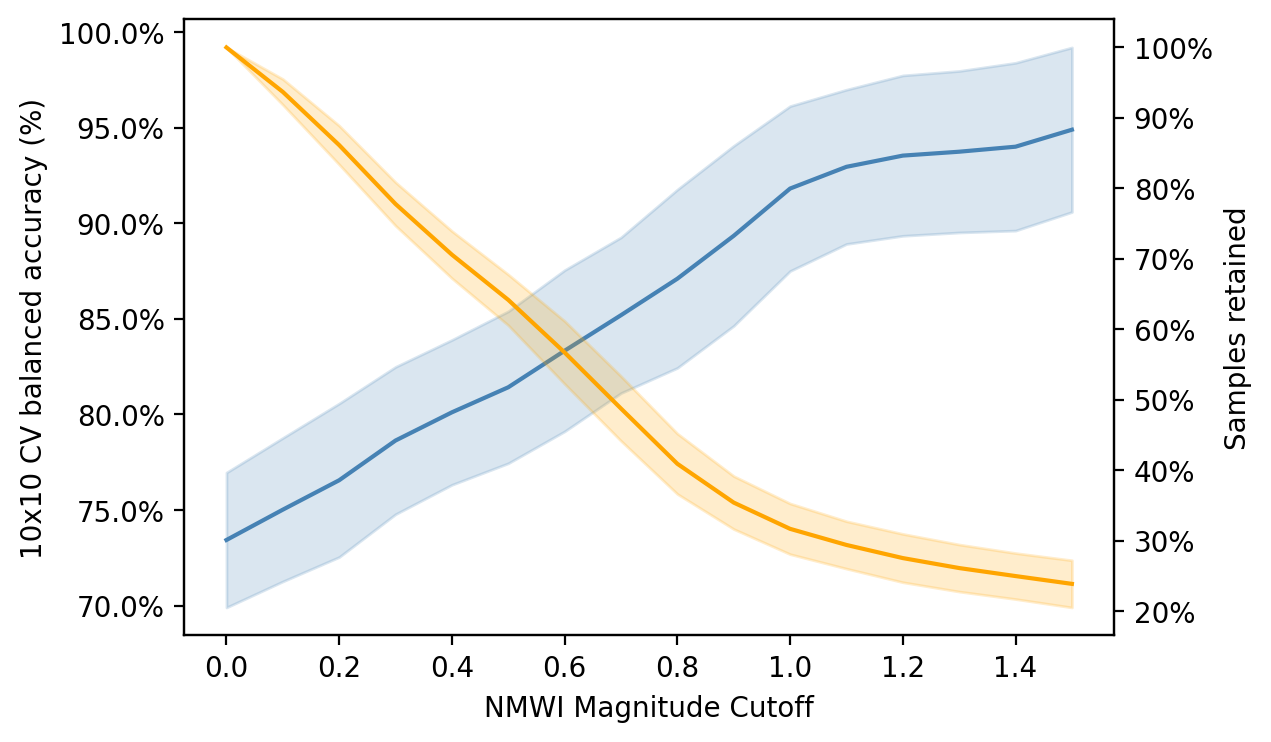

In [36]:
interval = 0.1
max_cutoff = 1.5
cutoffs = np.arange(0, max_cutoff + interval, interval)
y_arr = y.values
results = {
    c: {"bal_acc": [], "recall": [], "tnr": [], "samples_retained": []}
    for c in cutoffs
}

# Build and store the exact repeated 10x10 splits once
n_splits, n_repeats = 10, 10


for tr, te in cv_splits:
    X_tr, X_te = X_new.iloc[tr], X_new.iloc[te]
    y_tr, y_te = y_arr[tr], y_arr[te]

    model_10 = LogisticRegression(**final_params)
    model_10.fit(X_tr, y_tr)

    fold_scores = model_10.decision_function(X_te)

    for c in cutoffs:
        # Keep only samples with score magnitude above cutoff
        keep = np.abs(fold_scores) >= c
        if not np.any(keep):
            continue

        # Use the filtered test set and model.predict() to avoid threshold mismatch
        X_keep = X_te.iloc[keep]
        y_keep = y_te[keep]
        y_pred = model_10.predict(X_keep)

        ba = balanced_accuracy_score(y_keep, y_pred)
        rec = recall_score(y_keep, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_keep, y_pred, labels=[0, 1]).ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        results[c]["bal_acc"].append(ba)
        results[c]["recall"].append(rec)
        results[c]["tnr"].append(tnr)
        results[c]["samples_retained"].append(keep.mean())
        

# Summarize across all folds
df_cutoff = pd.DataFrame([
    {
        "cutoff": c,
        "samples retained": np.nanmean(results[c]["samples_retained"]),
        "samples retained sd": np.nanstd(results[c]["samples_retained"]),
        "bal_acc": np.nanmean(results[c]["bal_acc"]),
        "bal_acc sd": np.nanstd(results[c]["bal_acc"]),
        "recall": np.nanmean(results[c]["recall"]),
        "tnr": np.nanmean(results[c]["tnr"]),
    }
    for c in cutoffs
])

display(df_cutoff)
fig, ax1 = plt.subplots(figsize=(6, 4), dpi=200)
ax2 = ax1.twinx()

x = df_cutoff["cutoff"]

bal = df_cutoff["bal_acc"]
bal_sd = df_cutoff["bal_acc sd"]

ret = df_cutoff["samples retained"]
ret_sd = df_cutoff["samples retained sd"]

ax1.plot(x, bal, color="steelblue")
ax1.fill_between(
    x,
    bal - bal_sd,
    bal + bal_sd,
    color="steelblue",
    alpha=0.2
)

ax2.plot(x, ret, color="orange")
ax2.fill_between(
    x,
    ret - ret_sd,
    ret + ret_sd,
    color="orange",
    alpha=0.2
)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

ax1.set_ylabel("10x10 CV balanced accuracy (%)", fontsize=10)
ax2.set_ylabel("Samples retained", fontsize=10)
ax1.set_xlabel("NMWI Magnitude Cutoff", fontsize=10)

# plt.savefig('Figures/Fig3d.pdf')
plt.show()


### Figure 4.e
Balanced accuracies at selected magnitude cutoffs (0, 0.5, 1) under (e) 10×10 CV and (f) resubstitution. Bars show group performance; green lines indicate retained samples.

    cutoff  samples retained  samples retained sd   bal_acc  bal_acc sd  \
0      0.0          1.000000             0.000000  0.734349    0.035282   
5      0.5          0.641903             0.036007  0.814238    0.039744   
10     1.0          0.317161             0.035954  0.918187    0.043131   

      recall       tnr  
0   0.773869  0.694829  
5   0.879525  0.748951  
10  0.918451  0.917923  


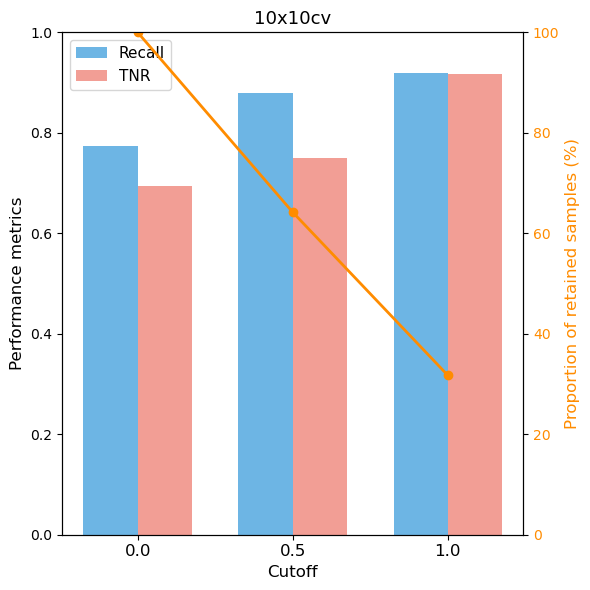

In [38]:
def plot_cutoff_summary(df, title="LOSO", cutoffs=(0, 0.5, 1)):
    df = df.copy()
    df["cutoff"] = pd.to_numeric(df["cutoff"], errors="coerce")
    df_plot = df[df["cutoff"].isin(cutoffs)].sort_values("cutoff")

    print(df_plot)

    fig, ax1 = plt.subplots(figsize=(6, 6))

    bar_width = 0.35
    x = np.arange(len(df_plot))

    ax1.bar(
        x - bar_width / 2,
        df_plot["recall"],
        width=bar_width,
        label="Recall",
        color="#5DADE2",
        alpha=0.9
    )
    ax1.bar(
        x + bar_width / 2,
        df_plot["tnr"],
        width=bar_width,
        label="TNR",
        color="#F1948A",
        alpha=0.9
    )

    ax1.set_ylabel("Performance metrics", fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_plot["cutoff"], fontsize=12)
    ax1.set_xlabel("Cutoff", fontsize=12)

    ax2 = ax1.twinx()
    ax2.plot(
        x,
        df_plot["samples retained"] * 100,
        marker="o",
        color="darkorange",
        linewidth=2
    )
    ax2.set_ylabel("Proportion of retained samples (%)", color="darkorange", fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis="y", labelcolor="darkorange")

    ax1.legend(loc="upper left", fontsize=11)
    plt.title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig('Figures/Fig3e_2.pdf')
    plt.show()

plot_cutoff_summary(df_cutoff, title="10x10cv")

### Figure 4.f

,cutoff,samples retained,samples retained sd,bal_acc,bal_acc sd,recall,tnr
0,0.0,1.000000,0.0,0.743743,0.0,0.786078,0.701408
1,0.1,0.940145,0.0,0.757540,0.0,0.803636,0.711443
2,0.2,0.864571,0.0,0.778385,0.0,0.832335,0.724435
3,0.3,0.780532,0.0,0.803917,0.0,0.876652,0.731183
4,0.4,0.714027,0.0,0.812755,0.0,0.887290,0.738220
5,0.5,0.656590,0.0,0.822756,0.0,0.892670,0.752841
6,0.6,0.579202,0.0,0.844080,0.0,0.899110,0.789050
7,0.7,0.509674,0.0,0.862822,0.0,0.892617,0.833028
8,0.8,0.419589,0.0,0.886861,0.0,0.902542,0.871179
9,0.9,0.362757,0.0,0.914377,0.0,0.926316,0.902439


    cutoff  samples retained  samples retained sd   bal_acc  bal_acc sd  \
0      0.0          1.000000                  0.0  0.743743         0.0   
5      0.5          0.656590                  0.0  0.822756         0.0   
10     1.0          0.326481                  0.0  0.932606         0.0   

      recall       tnr  
0   0.786078  0.701408  
5   0.892670  0.752841  
10  0.935673  0.929539  


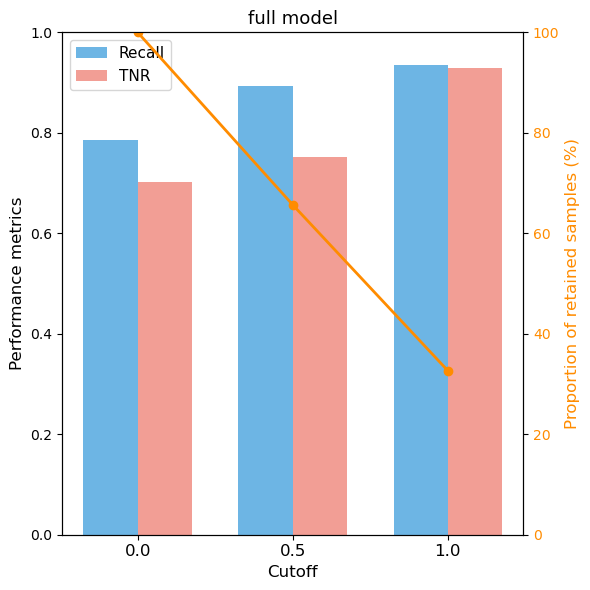

In [39]:
### Full model
final_params = dict(
    random_state=42,
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    C=C,
    max_iter=2000
)

NMWI = LogisticRegression(**final_params)
NMWI.fit(X_new, y.values.ravel())

y_arr = y.values.ravel()
y_train_pred = NMWI.predict(X_new)
scores_all = NMWI.decision_function(X_new)
train_bal_acc = balanced_accuracy_score(y_arr, y_train_pred)

coef = NMWI.coef_.flatten()
feature_names = X_new.columns

coefficients = pd.DataFrame(coef, index=feature_names, columns=["Coefficient"])
sorted_coefficients = coefficients.sort_values("Coefficient", ascending=False)
NMWI_coefs = sorted_coefficients[
    (sorted_coefficients["Coefficient"] > 0) | (sorted_coefficients["Coefficient"] < 0)
]
NMWI_coefs.reset_index().to_csv("NMWI_coefficients.csv", index=False)

num_pos = (sorted_coefficients["Coefficient"] > 0).sum()
num_neg = (sorted_coefficients["Coefficient"] < 0).sum()
num_zero = (sorted_coefficients["Coefficient"] == 0).sum()
num_coef = len(sorted_coefficients)

results_full = {
    c: {"bal_acc": [], "recall": [], "tnr": [], "samples_retained": []}
    for c in cutoffs
}

for c in cutoffs:
    keep = np.abs(scores_all) >= c
    if not np.any(keep):
        continue

    X_keep = X_new.iloc[keep]
    y_keep = y_arr[keep]
    y_pred = NMWI.predict(X_keep)

    ba = balanced_accuracy_score(y_keep, y_pred)
    rec = recall_score(y_keep, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_keep, y_pred, labels=[0, 1]).ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    results_full[c]["bal_acc"].append(ba)
    results_full[c]["recall"].append(rec)
    results_full[c]["tnr"].append(tnr)
    results_full[c]["samples_retained"].append(keep.mean())

df_cutoff_full = pd.DataFrame([
    {
        "cutoff": c,
        "samples retained": np.nanmean(results_full[c]["samples_retained"]),
        "samples retained sd": np.nanstd(results_full[c]["samples_retained"]),
        "bal_acc": np.nanmean(results_full[c]["bal_acc"]),
        "bal_acc sd": np.nanstd(results_full[c]["bal_acc"]),
        "recall": np.nanmean(results_full[c]["recall"]),
        "tnr": np.nanmean(results_full[c]["tnr"]),
    }
    for c in cutoffs
])

display(df_cutoff_full)

plot_cutoff_summary(df_cutoff_full, title="full model")
